# GWAS Diversity Monitor: growth and representation, 2005–2026

This notebook develops a publication-ready candidate figure for a second *Nature Genetics* Correspondence. It is deliberately a scientific figure rather than a dashboard screenshot: every panel is regenerated from the local NHGRI–EBI GWAS Catalog snapshot and the monitor's funder/cohort metadata.

The central editorial claim is that **GWAS output has expanded dramatically, while participant representation has changed only marginally at the aggregate level—and the new funder/cohort views reveal where that aggregate conceals consequential heterogeneity**.

Reference points:

- Original monitor repository release: 8 November 2019 (repository history).
- Original Correspondence: Mills & Rahal, “[The GWAS Diversity Monitor tracks diversity by disease in real time](https://www.nature.com/articles/s41588-020-0580-y),” *Nature Genetics* 52, 242–243 (published 5 March 2020).
- Funder/cohort development release: 27 August 2026 (repository history; editable below before submission).
- Population labels follow the [GWAS Catalog population-descriptor framework](https://www.ebi.ac.uk/gwas/docs/population-descriptors).


## Figure logic

The eleven panels form one argument:

- **A–C:** growth in publications, accessioned GWAS analyses, and participant instances.
- **D–H:** discovery/replication ancestry, annual non-European representation, and matched funder/cohort diversity summaries.
- **I–K:** concentration of linked publications and the full cohort/funder diversity landscapes.

Two counting choices are important. First, “participants” means **participant instances across GWAS accessions**, not deduplicated people; the same person or biobank may contribute to multiple analyses. Second, funders and cohorts use **full counting**: an accession contributes its complete ancestry profile to every funder or cohort linked to it. Cohort panels therefore describe the ancestry profile of *GWAS linked to a cohort*, not the demographic composition of that cohort itself. These limitations are carried into the caption and source-data metadata.


In [1]:
# Imports, paths, journal dimensions, and the monitor's exact website palette
import datetime as dt
import json
import os
import re
import subprocess
import sys
import tempfile
from pathlib import Path

os.environ.setdefault(
    "MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "gwas-static-figure-mpl")
)

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import FancyBboxPatch, Patch
from matplotlib.ticker import FuncFormatter, MultipleLocator
import numpy as np
import pandas as pd
from IPython.display import display


HERE = Path.cwd().resolve()
REPO_ROOT = HERE if (HERE / "data").is_dir() else HERE.parent
if not (REPO_ROOT / "data").is_dir():
    raise FileNotFoundError("Run this notebook from the repository or static_figure directory.")
OUTPUT_DIR = REPO_ROOT / "static_figure"
OUTPUT_DIR.mkdir(exist_ok=True)
OVERLEAF_FIGURE_PATH = Path(
    "/home/porco/CharlieRahal Dropbox/Charlie RAHAL/Apps/Overleaf/"
    "gwas_diversity_by_funder_and_cohort/figure_1.pdf"
)
sys.path.insert(0, str(REPO_ROOT))

import funder_pipeline


# Exact Sass variables from app/static/sass/imports/_variables.scss.
SITE = {
    "primary": "#374282",
    "light_primary": "#5c6bc0",
    "hover": "#97abed",
    "purple": "#212c8f",
    "dark_purple": "#0C145F",
    "content": "#4a4a4a",
    "blue_grey": "#78909c",
    "light_grey": "#e9edee",
    "paper": "#ffffff",
    "panel": "#f4f6fb",
}
ANCESTRY_ORDER = [
    "European",
    "Asian",
    "African",
    "African American or Afro-Caribbean",
    "Hispanic or Latin American",
    "Other/Mixed",
]
ANCESTRY_COLORS = {
    "European": "#ed7892",
    "Asian": "#489ed8",
    "African": "#f59c44",
    "African American or Afro-Caribbean": "#fece59",
    "Hispanic or Latin American": "#9767ab",
    "Other/Mixed": "#54bdbe",
}
ANCESTRY_SHORT = {
    "European": "European",
    "Asian": "Asian",
    "African": "African",
    "African American or Afro-Caribbean": "African Am./\nAfro-Carib.",
    "Hispanic or Latin American": "Hispanic/\nLat. Am.",
    "Other/Mixed": "Other/\nMixed",
}

# Editable milestones. Fractional-year placement is calculated from these dates.
RELEASE_EVENTS = [
    {"date": "2019-11-08", "label": "Repository\nrelease"},
    {"date": "2020-03-05", "label": "Nature Genetics\nCorrespondence"},
    {"date": "2026-08-27", "label": "Funder + cohort\ndev release"},
]
ORIGINAL_CORRESPONDENCE = {
    "publication_count": 4346,
    "european_participant_pct": 88.45,
    "published": "2020-03-05",
    "doi": "10.1038/s41588-020-0580-y",
}
ERA_BINS = [2004, 2010, 2015, 2020, 2027]
ERA_LABELS = ["2005–10", "2011–15", "2016–20", "2021–26"]
TOP_N = 10

font_path = REPO_ROOT / "app/static/fonts/PTSansNarrow/PTSansNarrow-Regular.ttf"
bold_font_path = REPO_ROOT / "app/static/fonts/PTSansNarrow/PTSansNarrow-Bold.ttf"
for path in (font_path, bold_font_path):
    if path.exists():
        font_manager.fontManager.addfont(str(path))
FONT_FAMILY = (
    font_manager.FontProperties(fname=str(font_path)).get_name()
    if font_path.exists() else "DejaVu Sans"
)

mpl.rcParams.update({
    "font.family": FONT_FAMILY,
    "font.size": 6.4,
    "axes.titlesize": 7.4,
    "axes.titleweight": "bold",
    "axes.labelsize": 6.2,
    "xtick.labelsize": 5.6,
    "ytick.labelsize": 5.6,
    "text.color": SITE["content"],
    "axes.labelcolor": "black",
    "axes.edgecolor": SITE["blue_grey"],
    "xtick.color": SITE["blue_grey"],
    "ytick.color": SITE["blue_grey"],
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
})

try:
    GIT_SHA = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], cwd=REPO_ROOT, text=True
    ).strip()
except (OSError, subprocess.CalledProcessError):
    GIT_SHA = "unavailable"

print(f"Repository: {REPO_ROOT}")
print(f"Output: {OUTPUT_DIR}")
print(f"Git revision: {GIT_SHA}")


Repository: /home/porco/CharlieRahal Dropbox/Charlie RAHAL/gwasdiversitymonitor/github/gwasdiversitymonitor
Output: /home/porco/CharlieRahal Dropbox/Charlie RAHAL/gwasdiversitymonitor/github/gwasdiversitymonitor/static_figure
Git revision: f1aaf41


## Load and validate the analysis snapshot

Only columns used by this figure are loaded. The notebook intentionally uses the monitor's harmonized ancestry file, PubMed grant cache, funder normalizer, and raw study metadata, so its results are consistent with the live application while remaining independently auditable.


In [2]:
study_columns = [
    "STUDY ACCESSION", "PUBMED ID", "DATE", "COHORT", "JOURNAL"
]
studies = pd.read_csv(
    REPO_ROOT / "data/catalog/raw/Cat_Stud.tsv",
    sep="\t", usecols=study_columns, dtype=str, low_memory=False,
).rename(columns={"PUBMED ID": "PUBMEDID"})
studies["PUBMEDID"] = studies["PUBMEDID"].map(funder_pipeline.normalize_pmid)
studies["DATE"] = pd.to_datetime(studies["DATE"], errors="coerce")
studies["Year"] = studies["DATE"].dt.year.astype("Int64")

ancestry_columns = [
    "STUDY ACCESSION", "PUBMEDID", "DATE", "STAGE", "N", "Broader"
]
ancestry = pd.read_csv(
    REPO_ROOT / "data/catalog/synthetic/Cat_Anc_wBroader.tsv",
    sep="\t", usecols=ancestry_columns, dtype={"PUBMEDID": str},
    low_memory=False,
)
ancestry["PUBMEDID"] = ancestry["PUBMEDID"].map(funder_pipeline.normalize_pmid)
ancestry["DATE"] = pd.to_datetime(ancestry["DATE"], errors="coerce")
ancestry["Year"] = ancestry["DATE"].dt.year.astype("Int64")
ancestry["N"] = pd.to_numeric(ancestry["N"], errors="coerce").fillna(0)

with open(REPO_ROOT / "data/summary/summary.json", encoding="utf-8") as source:
    monitor_summary = json.load(source)

required_study = {"STUDY ACCESSION", "PUBMEDID", "DATE", "COHORT"}
required_ancestry = {"STUDY ACCESSION", "PUBMEDID", "DATE", "STAGE", "N", "Broader"}
assert required_study.issubset(studies.columns)
assert required_ancestry.issubset(ancestry.columns)
assert set(ancestry["STAGE"].dropna().unique()).issubset({"initial", "replication"})
assert studies["STUDY ACCESSION"].nunique() == monitor_summary["number_accessions"]
assert studies["PUBMEDID"].nunique() == monitor_summary["number_studies"]

recorded = ancestry[
    ancestry["Broader"].isin(ANCESTRY_ORDER)
    & ancestry["Year"].notna()
].copy()
recorded["Year"] = recorded["Year"].astype(int)
studies_valid = studies[studies["Year"].notna()].copy()
studies_valid["Year"] = studies_valid["Year"].astype(int)

FIRST_YEAR = int(min(studies_valid["Year"].min(), recorded["Year"].min()))
LAST_YEAR = int(max(studies_valid["Year"].max(), recorded["Year"].max()))
YEARS = pd.Index(range(FIRST_YEAR, LAST_YEAR + 1), name="Year")
SNAPSHOT_DATE = pd.Timestamp(monitor_summary["timeupdated"])

print(
    f"Loaded {len(studies):,} accessions from {studies['PUBMEDID'].nunique():,} "
    f"publications and {len(ancestry):,} ancestry records."
)
print(f"Snapshot generated {SNAPSHOT_DATE}; publication years {FIRST_YEAR}–{LAST_YEAR}.")


Loaded 229,900 accessions from 7,797 publications and 298,217 ancestry records.
Snapshot generated 2026-08-30 23:01:58; publication years 2005–2026.


## Derive longitudinal growth and ancestry measures

Annual series are reconstructed from publication dates in the current snapshot. They are not archived year-end snapshots, so later Catalog backfilling can alter historical counts. The final year is partial and is marked as such in the figure.


In [3]:
annual = pd.DataFrame(index=YEARS)
annual["Publications"] = (
    studies_valid.groupby("Year")["PUBMEDID"].nunique().reindex(YEARS, fill_value=0)
)
annual["Accessions"] = (
    studies_valid.groupby("Year")["STUDY ACCESSION"].nunique().reindex(YEARS, fill_value=0)
)
stage_participants = (
    ancestry[ancestry["Year"].notna()]
    .assign(Year=lambda frame: frame["Year"].astype(int))
    .groupby(["Year", "STAGE"])["N"].sum()
    .unstack(fill_value=0)
    .reindex(YEARS, fill_value=0)
)
annual["Discovery participant instances"] = stage_participants.get("initial", 0)
annual["Replication participant instances"] = stage_participants.get("replication", 0)
annual["Cumulative publications"] = annual["Publications"].cumsum()
annual["Cumulative accessions"] = annual["Accessions"].cumsum()

annual_composition = {}
annual_non_european = pd.DataFrame(index=YEARS)
for stage, display_name in (("initial", "Discovery"), ("replication", "Replication")):
    stage_frame = recorded[recorded["STAGE"] == stage]
    counts = (
        stage_frame.groupby(["Year", "Broader"])["N"].sum()
        .unstack(fill_value=0)
        .reindex(index=YEARS, columns=ANCESTRY_ORDER, fill_value=0)
    )
    shares = counts.div(counts.sum(axis=1).replace(0, np.nan), axis=0) * 100
    annual_composition[stage] = shares
    annual_non_european[display_name] = 100 - shares["European"]

combined_counts = (
    recorded.groupby(["Year", "Broader"])["N"].sum()
    .unstack(fill_value=0)
    .reindex(index=YEARS, columns=ANCESTRY_ORDER, fill_value=0)
)
annual_non_european["All stages"] = (
    100 - combined_counts["European"] / combined_counts.sum(axis=1) * 100
)

overall_ancestry_counts = recorded.groupby("Broader")["N"].sum().reindex(
    ANCESTRY_ORDER, fill_value=0
)
overall_ancestry_pct = overall_ancestry_counts / overall_ancestry_counts.sum() * 100
CURRENT_EUROPEAN_PCT = float(overall_ancestry_pct["European"])
CURRENT_NON_EUROPEAN_PCT = 100 - CURRENT_EUROPEAN_PCT

annual.tail(8)


,Publications,Accessions,Discovery participant instances,Replication participant instances,Cumulative publications,Cumulative accessions
Year,,,,,,
2019,568,2568,156666599,26721112,4633,16646
2020,540,3597,293081155,24538863,5173,20243
2021,687,29272,3989117185,110039741,5860,49515
2022,621,33229,829108112,73500668,6481,82744
2023,560,21185,720253109,53919906,7041,103929
2024,385,33355,2828981817,41162072,7426,137284
2025,239,62208,2617039289,16052740,7665,199492
2026,132,30408,1881816430,92503391,7797,229900


## Funder-linked diversity

Funding agencies come from the cached PubMed GrantList and the monitor's version-controlled normalization map. All normalized funders linked to at least one ancestry-recorded GWAS are included; only the labelled ranking panel is limited to its top ten. Funding coverage is metadata coverage, not a claim that unfunded papers had no funder.


In [4]:
with open(REPO_ROOT / "data/funders/pubmed_grants.json", encoding="utf-8") as source:
    grant_cache = json.load(source)
cleaner = funder_pipeline.load_funder_cleaner(
    REPO_ROOT / "data/funders/funder_cleaner.json"
)
funding_by_publication = funder_pipeline.funding_names_by_publication(
    grant_cache, cleaner
)
funding_long = pd.DataFrame(
    [
        (pmid, funder)
        for pmid, funders in funding_by_publication.items()
        for funder in funders
    ],
    columns=["PUBMEDID", "Funder"],
).drop_duplicates()

ancestry_funder = recorded.merge(funding_long, on="PUBMEDID", how="inner")
funder_counts = (
    ancestry_funder.groupby(["Funder", "Broader"])["N"].sum()
    .unstack(fill_value=0)
    .reindex(columns=ANCESTRY_ORDER, fill_value=0)
)
funder_metrics = pd.DataFrame(index=funder_counts.index)
funder_metrics["Participant instances"] = funder_counts.sum(axis=1)
funder_metrics["Non-European %"] = (
    (funder_metrics["Participant instances"] - funder_counts["European"])
    / funder_metrics["Participant instances"] * 100
)
funder_metrics["Effective ancestry groups"] = (
    1 / (funder_counts.div(funder_counts.sum(axis=1), axis=0).pow(2).sum(axis=1))
)
funder_metrics["Publications"] = ancestry_funder.groupby("Funder")["PUBMEDID"].nunique()
funder_metrics["Accessions"] = ancestry_funder.groupby("Funder")["STUDY ACCESSION"].nunique()
funder_composition = funder_counts.div(funder_counts.sum(axis=1), axis=0) * 100

# Rank on linked publications rather than accessions, avoiding domination by
# papers that submit thousands of accessioned analyses.
top_funders = (
    funder_metrics.sort_values(["Publications", "Accessions"], ascending=False)
    .head(TOP_N).index.tolist()
)

ancestry_funder["Era"] = pd.cut(
    ancestry_funder["Year"], bins=ERA_BINS, labels=ERA_LABELS
)
funder_era_counts = (
    ancestry_funder
    .groupby(["Funder", "Era", "Broader"], observed=True)["N"].sum()
    .unstack(fill_value=0)
    .reindex(columns=ANCESTRY_ORDER, fill_value=0)
)
funder_era = (
    100 * (funder_era_counts.sum(axis=1) - funder_era_counts["European"])
    / funder_era_counts.sum(axis=1)
).rename("Non-European %").reset_index()

FUNDING_COVERAGE_PCT = (
    funding_long["PUBMEDID"].nunique() / studies["PUBMEDID"].nunique() * 100
)

funder_metrics.loc[top_funders].sort_values("Non-European %")


,Participant instances,Non-European %,Effective ancestry groups,Publications,Accessions
Funder,,,,,
Medical Research Council (UK),5724854528,4.793651,1.101973,1903,46308
Wellcome Trust,1954983922,11.912062,1.279537,1348,37742
NHLBI NIH HHS,1823256973,12.730771,1.303858,1609,33490
NIMH NIH HHS,2891883584,19.985475,1.518657,717,24867
NIA NIH HHS,3234291532,20.127185,1.528546,1004,65195
NHGRI NIH HHS,3668368852,21.955849,1.602662,1001,37417
NCRR NIH HHS,174047471,22.642270,1.629395,756,5966
NIDDK NIH HHS,2915624390,23.745393,1.658785,1054,48893
NCATS NIH HHS,2330870635,25.780136,1.721599,822,20669


## Cohort-linked diversity

The GWAS Catalog `COHORT` field is pipe-delimited. Exact cohort identifiers are retained except for a small, explicit alias map (`UKB`/`UKBB`; `Knight_ADRC`/`Knight-ADRC`) and cosmetic underscore replacement. `NR` and `other` are excluded. Cohorts are ranked by linked publications, not accession count, because one publication can create thousands of accessioned analyses.


In [5]:
COHORT_ALIASES = {
    "ukb": "UK Biobank (UKB)",
    "ukbb": "UK Biobank (UKB)",
    "knightadrc": "Knight ADRC",
}
COHORT_EXCLUSIONS = {"", "nr", "other", "notreported", "nan", "none"}


def canonical_cohort(value):
    text = str(value).strip()
    key = re.sub(r"[\s_-]+", "", text).casefold()
    if key in COHORT_EXCLUSIONS:
        return ""
    return COHORT_ALIASES.get(key, text.replace("_", " "))


cohort_membership = studies[
    ["STUDY ACCESSION", "PUBMEDID", "COHORT"]
].dropna(subset=["COHORT"]).copy()
cohort_membership["Cohort"] = cohort_membership["COHORT"].str.split("|")
cohort_membership = cohort_membership.explode("Cohort")
cohort_membership["Cohort"] = cohort_membership["Cohort"].map(canonical_cohort)
cohort_membership = cohort_membership[
    cohort_membership["Cohort"] != ""
].drop_duplicates(["STUDY ACCESSION", "Cohort"])

ancestry_cohort = recorded.merge(
    cohort_membership[["STUDY ACCESSION", "Cohort"]],
    on="STUDY ACCESSION", how="inner",
)
cohort_counts = (
    ancestry_cohort.groupby(["Cohort", "Broader"])["N"].sum()
    .unstack(fill_value=0)
    .reindex(columns=ANCESTRY_ORDER, fill_value=0)
)
cohort_metrics = pd.DataFrame(index=cohort_counts.index)
cohort_metrics["Participant instances"] = cohort_counts.sum(axis=1)
cohort_metrics["Non-European %"] = (
    (cohort_metrics["Participant instances"] - cohort_counts["European"])
    / cohort_metrics["Participant instances"] * 100
)
cohort_metrics["Effective ancestry groups"] = (
    1 / (cohort_counts.div(cohort_counts.sum(axis=1), axis=0).pow(2).sum(axis=1))
)
cohort_metrics["Publications"] = ancestry_cohort.groupby("Cohort")["PUBMEDID"].nunique()
cohort_metrics["Accessions"] = ancestry_cohort.groupby("Cohort")["STUDY ACCESSION"].nunique()
cohort_composition = cohort_counts.div(cohort_counts.sum(axis=1), axis=0) * 100

top_cohorts = (
    cohort_metrics.sort_values(["Publications", "Accessions"], ascending=False)
    .head(TOP_N).index.tolist()
)

ancestry_cohort["Era"] = pd.cut(
    ancestry_cohort["Year"], bins=ERA_BINS, labels=ERA_LABELS
)
cohort_era_counts = (
    ancestry_cohort
    .groupby(["Cohort", "Era", "Broader"], observed=True)["N"].sum()
    .unstack(fill_value=0)
    .reindex(columns=ANCESTRY_ORDER, fill_value=0)
)
cohort_era = (
    100 * (cohort_era_counts.sum(axis=1) - cohort_era_counts["European"])
    / cohort_era_counts.sum(axis=1)
).rename("Non-European %").reset_index()

COHORT_COVERAGE_PCT = (
    cohort_membership["STUDY ACCESSION"].nunique()
    / studies["STUDY ACCESSION"].nunique() * 100
)

cohort_metrics.loc[top_cohorts].sort_values("Non-European %")


,Participant instances,Non-European %,Effective ancestry groups,Publications,Accessions
Cohort,,,,,
UK Biobank (UKB),9759504890,2.907555,1.060438,788,59560
EB,614668545,7.365383,1.162498,66,1565
FinnGen,555100388,16.849784,1.422386,168,711
MVP,2289259839,24.997652,1.690134,96,8057
FHS,136616878,25.356877,1.715933,61,2133
CHS,139433325,26.414657,1.759202,56,2163
ARIC,150724766,31.280281,1.955154,66,2993
MESA,146185940,35.555343,2.133245,50,2392
BBJ,616673597,67.224377,2.152295,91,5066


## Audit the claims before drawing

These tables are intentionally left in the executed notebook. They provide a compact peer-review trail for the headline comparison and the entities selected for the funder/cohort panels.


In [6]:
headline_audit = pd.DataFrame({
    "Measure": [
        "Publications", "GWAS accessions", "European participant share",
        "Analyzed funders", "Meaningful cohort labels",
        "Funding metadata coverage", "Cohort metadata coverage",
    ],
    "2020 Correspondence": [
        ORIGINAL_CORRESPONDENCE["publication_count"], np.nan,
        ORIGINAL_CORRESPONDENCE["european_participant_pct"],
        np.nan, np.nan, np.nan, np.nan,
    ],
    "Current snapshot": [
        studies["PUBMEDID"].nunique(), studies["STUDY ACCESSION"].nunique(),
        CURRENT_EUROPEAN_PCT, len(funder_metrics),
        cohort_membership["Cohort"].nunique(),
        FUNDING_COVERAGE_PCT, COHORT_COVERAGE_PCT,
    ],
})
display(headline_audit.round(2))
display(
    funder_metrics.loc[top_funders, ["Publications", "Accessions", "Non-European %"]]
    .sort_values("Publications", ascending=False).round(2)
)
display(
    cohort_metrics.loc[top_cohorts, ["Publications", "Accessions", "Non-European %"]]
    .sort_values("Publications", ascending=False).round(2)
)


,Measure,2020 Correspondence,Current snapshot
0,Publications,4346.00,7797.00
1,GWAS accessions,NaN,229900.00
2,European participant share,88.45,88.20
3,Analyzed funders,NaN,1138.00
4,Meaningful cohort labels,NaN,1426.00
5,Funding metadata coverage,NaN,71.82
6,Cohort metadata coverage,NaN,88.73


,Publications,Accessions,Non-European %
Funder,,,
Medical Research Council (UK),1903,46308,4.79
NHLBI NIH HHS,1609,33490,12.73
Wellcome Trust,1348,37742,11.91
NIDDK NIH HHS,1054,48893,23.75
NCI NIH HHS,1051,12445,26.27
NIA NIH HHS,1004,65195,20.13
NHGRI NIH HHS,1001,37417,21.96
NCATS NIH HHS,822,20669,25.78
NCRR NIH HHS,756,5966,22.64


,Publications,Accessions,Non-European %
Cohort,,,
UK Biobank (UKB),788,59560,2.91
FinnGen,168,711,16.85
MVP,96,8057,25.00
BBJ,91,5066,67.22
ARIC,66,2993,31.28
EB,66,1565,7.37
FHS,61,2133,25.36
CHS,56,2163,26.41
KoGES,52,476,73.02


## Draw the integrated 12-panel figure

The canvas is 180 mm wide, matching a full-width two-column journal figure. All app ancestry colors are preserved exactly. Vector PDF and SVG are the primary outputs; the 600-dpi PNG is for editorial preview.


/tmp/ipykernel_152788/390768654.py:588: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) PT Sans Narrow.
  fig.savefig(pdf_path, **tight_export)


/tmp/ipykernel_152788/390768654.py:589: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) PT Sans Narrow.
  fig.savefig(svg_path, **tight_export)


/tmp/ipykernel_152788/390768654.py:590: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) PT Sans Narrow.
  fig.savefig(png_path, dpi=600, **tight_export)


/tmp/ipykernel_152788/390768654.py:591: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) PT Sans Narrow.
  fig.savefig(OVERLEAF_FIGURE_PATH, **tight_export)


/home/porco/miniforge3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 961 (\N{GREEK SMALL LETTER RHO}) missing from font(s) PT Sans Narrow.
  fig.canvas.print_figure(bytes_io, **kw)


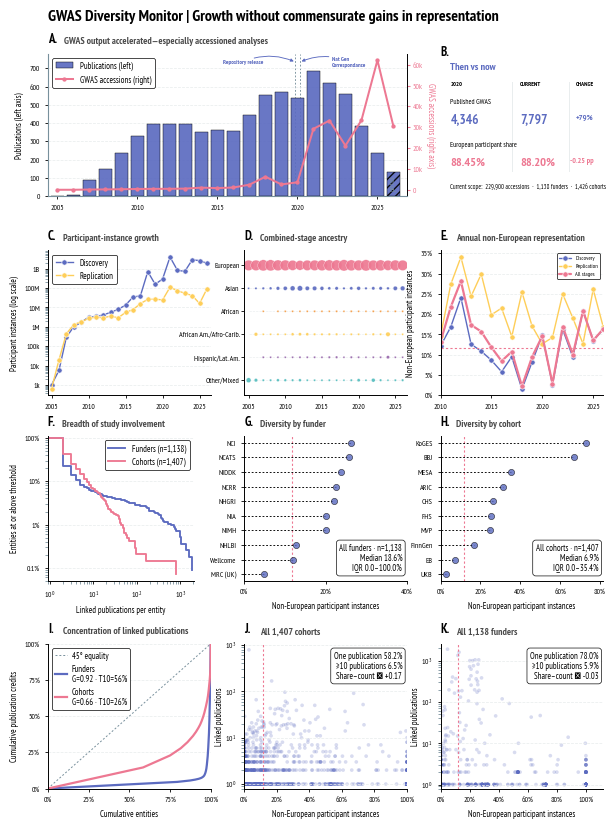

Saved gwas_growth_diversity_main_figure.pdf, gwas_growth_diversity_main_figure.svg, and gwas_growth_diversity_main_figure.png
Saved Overleaf-ready figure to /home/porco/CharlieRahal Dropbox/Charlie RAHAL/Apps/Overleaf/gwas_diversity_by_funder_and_cohort/figure_1.pdf


In [7]:
def human_number(value, _position=None):
    value = float(value)
    for scale, suffix in ((1e9, "B"), (1e6, "M"), (1e3, "k")):
        if abs(value) >= scale:
            return f"{value / scale:g}{suffix}"
    return f"{value:g}"


def percent_tick(value, _position=None):
    return f"{value:g}%"


def decimal_year(date_value):
    timestamp = pd.Timestamp(date_value)
    start = pd.Timestamp(timestamp.year, 1, 1)
    end = pd.Timestamp(timestamp.year + 1, 1, 1)
    return timestamp.year + (timestamp - start) / (end - start)


def clean_axis(ax, ygrid=False):
    ax.spines["left"].set_color("black")
    ax.spines["bottom"].set_color("black")
    ax.spines["left"].set_linewidth(0.7)
    ax.spines["bottom"].set_linewidth(0.7)
    ax.tick_params(length=2.2, width=0.6, colors="black", labelcolor="black")
    if ygrid:
        ax.grid(
            axis="y", color=SITE["light_grey"], linewidth=0.55,
            linestyle="--", zorder=0,
        )
    return ax


def panel_label(ax, letter, x=-0.14, y=1.06):
    ax.text(
        x, y, f"{letter}.", transform=ax.transAxes, color="black",
        fontsize=9.2, fontweight="bold", va="top", ha="left", clip_on=False,
    )


def contained_panel_heading(ax, letter, title, subtitle, title_x=0.095):
    """Give compact panels distinct, non-overlapping heading lanes."""
    ax.set_title("", loc="left")
    ax.text(
        0.0, 1.055, f"{letter}.", transform=ax.transAxes,
        color="black", fontsize=9.2, fontweight="bold",
        ha="left", va="bottom", clip_on=False,
    )
    ax.text(
        title_x, 1.055, title, transform=ax.transAxes,
        color=SITE["content"], fontsize=7.0, fontweight="bold",
        ha="left", va="bottom", clip_on=False,
    )


def short_funder(name):
    replacements = {
        "Medical Research Council (UK)": "MRC (UK)",
        "Wellcome Trust": "Wellcome",
        "Intramural NIH HHS": "NIH intramural",
    }
    if name in replacements:
        return replacements[name]
    return name.replace(" NIH HHS", "").replace(" (UK)", "")


def diversity_lollipop(ax, metrics, order, label_function, title):
    values = metrics.loc[order, "Non-European %"]
    y = np.arange(len(order))
    ax.hlines(
        y, 0, values, color="black", linewidth=0.65,
        linestyle=(0, (2, 2)), zorder=1,
    )
    ax.scatter(
        values, y, s=20, color=SITE["light_primary"], alpha=0.82,
        edgecolor="black", linewidth=0.4, zorder=2,
    )
    ax.axvline(CURRENT_NON_EUROPEAN_PCT, color=ANCESTRY_COLORS["European"],
               linewidth=0.8, linestyle=(0, (2, 2)), zorder=0)
    ax.set_yticks(y, [label_function(name) for name in order])
    ax.set_xlim(0, max(40, float(values.max()) * 1.12))
    ax.set_xlabel("Non-European participant instances")
    ax.xaxis.set_major_formatter(FuncFormatter(percent_tick))
    ax.set_title(title, loc="left", pad=4)
    ax.xaxis.set_major_locator(MultipleLocator(20))
    clean_axis(ax, ygrid=False)
    return ax


def diversity_summary_inset(ax, metrics, entity_label):
    values = metrics["Non-European %"].dropna()
    q1, median, q3 = values.quantile([0.25, 0.50, 0.75])
    ax.text(
        0.97, 0.055,
        f"All {entity_label} · n={len(values):,}\n"
        f"Median {median:.1f}%\nIQR {q1:.1f}–{q3:.1f}%",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=6.2,
        color="black", zorder=10,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white",
              "edgecolor": "black", "linewidth": 0.5, "alpha": 0.94},
    )


def publication_summary_inset(ax, metrics, entity_label):
    paired = metrics[["Publications", "Non-European %"]].dropna()
    publications = paired["Publications"]
    singleton_pct = publications.eq(1).mean() * 100
    established_pct = publications.ge(10).mean() * 100
    spearman_rho = paired["Non-European %"].rank().corr(publications.rank())
    ax.text(
        0.97, 0.95,
        f"One publication {singleton_pct:.1f}%\n"
        f"≥10 publications {established_pct:.1f}%\n"
        f"Share–count ρ {spearman_rho:+.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=6.2,
        color="black", zorder=10,
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white",
              "edgecolor": "black", "linewidth": 0.5, "alpha": 0.94},
    )


def ancestry_stacks(
        ax, composition, order, title="Complete ancestry mix",
        show_order_scale=False):
    left = np.zeros(len(order))
    for ancestry_name in ANCESTRY_ORDER:
        values = composition.loc[order, ancestry_name].to_numpy()
        ax.barh(
            np.arange(len(order)), values, left=left,
            height=0.86 if len(order) > 15 else 0.68,
            color=ANCESTRY_COLORS[ancestry_name], edgecolor="white",
            linewidth=0.12 if len(order) > 15 else 0.2,
        )
        left += values
    ax.set_xlim(0, 100)
    if show_order_scale:
        ax.set_yticks(np.arange(len(order)), [])
        for y_position, label in ((0.02, "Lower"), (0.98, "Higher")):
            ax.text(
                0.01, y_position, label, transform=ax.transAxes,
                ha="left", va="bottom" if label == "Lower" else "top",
                fontsize=4.5, color=SITE["blue_grey"], zorder=5,
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.8,
                      "pad": 0.2},
            )
    else:
        ax.set_yticks(np.arange(len(order)), [])
    ax.set_xlabel("Ancestry composition")
    ax.xaxis.set_major_formatter(FuncFormatter(percent_tick))
    ax.set_title(title, loc="left", pad=10 if len(order) > 15 else 4)
    ax.xaxis.set_major_locator(MultipleLocator(50))
    clean_axis(ax)
    return ax


site_sequential = LinearSegmentedColormap.from_list(
    "gwas_site", [SITE["panel"], SITE["hover"], SITE["light_primary"]]
)
site_sequential.set_bad("#d9dbdf")


def concentration_values(counts):
    values = np.sort(pd.Series(counts).dropna().to_numpy(dtype=float))
    shares = values / values.sum()
    entity_share = np.arange(len(values) + 1) / len(values) * 100
    cumulative_share = np.r_[0, np.cumsum(shares)] * 100
    gini = 1 - 2 * np.trapezoid(cumulative_share / 100, entity_share / 100)
    top10_share = np.sort(shares)[-min(10, len(shares)):].sum() * 100
    effective_n = 1 / np.square(shares).sum()
    stats = {"Gini": gini, "Top 10 share (%)": top10_share,
             "Effective number": effective_n}
    return entity_share, cumulative_share, stats


funder_order = (
    funder_metrics.loc[top_funders].sort_values("Non-European %").index.tolist()
)
cohort_order = (
    cohort_metrics.loc[top_cohorts].sort_values("Non-European %").index.tolist()
)

fig = plt.figure(figsize=(6.5354, 8.35), facecolor="white")  # 166 × 212 mm
grid = fig.add_gridspec(
    7, 12, height_ratios=[1.30, 0.42, 1.32, 0.30, 1.32, 0.50, 1.32],
    hspace=0.04, wspace=2.15,
)

# A — annual publications and accessions
ax_a = fig.add_subplot(grid[0, :8])
bars = ax_a.bar(
    annual.index, annual["Publications"], width=0.78,
    color=SITE["light_primary"], alpha=0.92, edgecolor="k",
    linewidth=0.35, zorder=2, label="Publications (left)",
)
bars[-1].set_hatch("////")
bars[-1].set_edgecolor("black")
ax_a.set_ylabel("Publications (left axis)", color="black")
ax_a.tick_params(axis="y", colors="black", labelcolor="black")
ax_a.set_xlim(FIRST_YEAR - 0.6, LAST_YEAR + 0.85)
ax_a.set_ylim(0, 780)
ax_a.set_xticks([2005, 2010, 2015, 2020, 2025])
ax_a.set_title("")
clean_axis(ax_a, ygrid=True)

ax_a2 = ax_a.twinx()
accession_line, = ax_a2.plot(
    annual.index, annual["Accessions"], color=ANCESTRY_COLORS["European"],
    linewidth=1.45, marker="o", markersize=2.1, zorder=3,
    label="GWAS accessions (right)",
)
ax_a2.set_ylabel(
    "GWAS accessions (right axis)", color=ANCESTRY_COLORS["European"],
    rotation=270, labelpad=9,
)
ax_a2.tick_params(
    axis="y", colors=ANCESTRY_COLORS["European"],
    labelcolor=ANCESTRY_COLORS["European"], length=2.2, pad=2
)
ax_a2.spines["right"].set_visible(True)
ax_a2.spines["right"].set_color("black")
ax_a2.spines["right"].set_linewidth(0.7)
ax_a2.yaxis.set_major_formatter(FuncFormatter(human_number))
legend_a = ax_a.legend(
    handles=[bars, accession_line], loc="upper left", fontsize=6.2,
    frameon=True, facecolor="w", edgecolor="k", framealpha=1.0,
)
legend_a.get_frame().set_linewidth(0.5)
plt.setp(legend_a.get_texts(), color="black")

event_specs = [
    (RELEASE_EVENTS[0], "Repository release", "right", -2.0, -0.22),
    (RELEASE_EVENTS[1], "Nat Gen\nCorrespondance", "left", 2.0, 0.22),
]
for event, label, alignment, x_offset, curve in event_specs:
    x_position = decimal_year(event["date"])
    ax_a.axvline(x_position, color=SITE["blue_grey"], linewidth=0.65,
                 linestyle=(0, (2, 2)), zorder=1)
    ax_a.annotate(
        label, xy=(x_position, 735), xytext=(x_position + x_offset, 735),
        ha=alignment, va="center",
        fontsize=4.4, fontweight="bold", color=SITE["light_primary"],
        bbox={"facecolor": "white", "edgecolor": "none",
              "alpha": 0.86, "pad": 0.5},
        arrowprops={"arrowstyle": "-|>", "color": SITE["light_primary"],
                    "linewidth": 0.65, "shrinkA": 2, "shrinkB": 1,
                    "connectionstyle": f"arc3,rad={curve}"},
    )
ax_a.text(
    LAST_YEAR, 0.04, "partial", transform=ax_a.get_xaxis_transform(),
    rotation=90, ha="center", va="bottom", fontsize=4.8, color=SITE["blue_grey"],
)
contained_panel_heading(
    ax_a, "A", "GWAS output accelerated—especially accessioned analyses", "",
    title_x=0.045,
)

# B — original Correspondence versus current snapshot
ax_b = fig.add_subplot(grid[0, 8:])
ax_b.set_axis_off()
ax_b.add_patch(FancyBboxPatch(
    (0, 0), 1, 1, boxstyle="round,pad=0.018,rounding_size=0.02",
    transform=ax_b.transAxes, facecolor="white", edgecolor=SITE["light_grey"],
    linewidth=0.8,
))
ax_b.text(0.06, 0.94, "Then vs now", transform=ax_b.transAxes,
          fontsize=7.4, fontweight="bold", color=SITE["light_primary"], va="top")
publication_growth = (
    studies["PUBMEDID"].nunique() / ORIGINAL_CORRESPONDENCE["publication_count"] - 1
) * 100
european_change = (
    CURRENT_EUROPEAN_PCT
    - ORIGINAL_CORRESPONDENCE["european_participant_pct"]
)

# Explicit columns avoid relying on spaces or separator glyphs for alignment.
column_x = {"then": 0.06, "now": 0.49, "change": 0.94}
for key, label, alignment in (
    ("then", "2020", "left"),
    ("now", "CURRENT", "left"),
    ("change", "CHANGE", "right"),
):
    ax_b.text(
        column_x[key], 0.78, label, transform=ax_b.transAxes,
        fontsize=4.5, fontweight="bold", color="black", ha=alignment,
    )
ax_b.plot([0.44, 0.44], [0.18, 0.80], transform=ax_b.transAxes,
          color=SITE["light_grey"], linewidth=0.7)
ax_b.plot([0.79, 0.79], [0.18, 0.80], transform=ax_b.transAxes,
          color=SITE["light_grey"], linewidth=0.7)

ax_b.text(0.06, 0.65, "Published GWAS", transform=ax_b.transAxes,
          fontsize=5.2, color="black")
ax_b.text(
    column_x["then"], 0.52,
    f"{ORIGINAL_CORRESPONDENCE['publication_count']:,}",
    transform=ax_b.transAxes, fontsize=9.6, fontweight="bold", color=SITE["light_primary"],
)
ax_b.text(
    column_x["now"], 0.52, f"{studies['PUBMEDID'].nunique():,}",
    transform=ax_b.transAxes, fontsize=9.6, fontweight="bold", color=SITE["light_primary"],
)
ax_b.text(
    column_x["change"], 0.54, f"+{publication_growth:.0f}%",
    transform=ax_b.transAxes, fontsize=6.0, fontweight="bold", ha="right",
    color=SITE["light_primary"],
)

ax_b.text(0.06, 0.35, "European participant share", transform=ax_b.transAxes,
          fontsize=5.2, color="black")
ax_b.text(
    column_x["then"], 0.22,
    f"{ORIGINAL_CORRESPONDENCE['european_participant_pct']:.2f}%",
    transform=ax_b.transAxes, fontsize=8.9, fontweight="bold",
    color=ANCESTRY_COLORS["European"],
)
ax_b.text(
    column_x["now"], 0.22, f"{CURRENT_EUROPEAN_PCT:.2f}%",
    transform=ax_b.transAxes, fontsize=8.9, fontweight="bold",
    color=ANCESTRY_COLORS["European"],
)
ax_b.text(
    column_x["change"], 0.24, f"{european_change:+.2f} pp",
    transform=ax_b.transAxes, fontsize=5.6, fontweight="bold", ha="right",
    color=ANCESTRY_COLORS["European"],
)
ax_b.text(
    0.06, 0.055,
    f"Current scope:  {studies['STUDY ACCESSION'].nunique():,} accessions  ·  "
    f"{len(funder_metrics):,} funders  ·  {cohort_membership['Cohort'].nunique():,} cohorts",
    transform=ax_b.transAxes, fontsize=4.7, color="black",
)
panel_label(ax_b, "B", x=0.0)

# C — participant-instance growth
ax_c = fig.add_subplot(grid[2, :4])
for column, color, label in (
    ("Discovery participant instances", SITE["light_primary"], "Discovery"),
    ("Replication participant instances", ANCESTRY_COLORS["African American or Afro-Caribbean"], "Replication"),
):
    ax_c.plot(
        annual.index, annual[column].replace(0, np.nan), color=color,
        linewidth=1.0, marker="o", markersize=3.8, label=label,
        markeredgecolor="white", markeredgewidth=0.45,
    )
ax_c.set_yscale("log")
ax_c.yaxis.set_major_formatter(FuncFormatter(human_number))
ax_c.set_xlim(FIRST_YEAR - 0.5, LAST_YEAR + 0.5)
ax_c.set_xticks([2005, 2010, 2015, 2020, 2025])
ax_c.set_ylabel("Participant instances (log scale)")
legend_c = ax_c.legend(
    frameon=True, facecolor="w", edgecolor="k", framealpha=1.0,
    fontsize=6.2, loc="upper left",
)
legend_c.get_frame().set_linewidth(0.5)
plt.setp(legend_c.get_texts(), color="black")
clean_axis(ax_c, ygrid=True)
contained_panel_heading(
    ax_c, "C", "Participant-instance growth",
    "Annual totals · log y-axis",
)

# D — annual ancestry composition with discovery and replication combined.
# Colour identifies ancestry; marker area represents the annual participant share.
dot_ancestry_order = list(reversed(ANCESTRY_ORDER))
dot_labels = {
    "European": "European",
    "Asian": "Asian",
    "African": "African",
    "African American or Afro-Caribbean": "African Am./Afro-Carib.",
    "Hispanic or Latin American": "Hispanic/Lat. Am.",
    "Other/Mixed": "Other/Mixed",
}
ax_d = fig.add_subplot(grid[2, 4:8])
combined_shares = combined_counts.div(
    combined_counts.sum(axis=1).replace(0, np.nan), axis=0
) * 100
for y_position, ancestry_name in enumerate(dot_ancestry_order):
    values = combined_shares[ancestry_name].fillna(0).to_numpy()
    visible_sizes = np.where(values > 0, 2.0 + 0.65 * values, 0)
    ax_d.hlines(
        y_position, FIRST_YEAR, LAST_YEAR, color=SITE["light_grey"],
        linewidth=0.45, linestyle="--", zorder=0,
    )
    ax_d.scatter(
        YEARS, np.full(len(YEARS), y_position), s=visible_sizes,
        color=(SITE["light_primary"] if ancestry_name == "Asian"
               else ANCESTRY_COLORS[ancestry_name]), alpha=0.92,
        edgecolor="white", linewidth=0.22, zorder=2,
    )
ax_d.set_xlim(FIRST_YEAR - 0.6, LAST_YEAR + 0.6)
ax_d.set_ylim(-0.65, len(dot_ancestry_order) - 0.35)
ax_d.set_xticks([2005, 2010, 2015, 2020, 2025])
ax_d.set_yticks(
    range(len(dot_ancestry_order)),
    [dot_labels[name] for name in dot_ancestry_order],
)
ax_d.tick_params(axis="y", labelleft=True, pad=1)
clean_axis(ax_d)
contained_panel_heading(ax_d, "D", "Combined-stage ancestry", "")

# E — non-European representation over time
ax_e = fig.add_subplot(grid[2, 8:])
for column, color, width in (
    ("Discovery", SITE["light_primary"], 1.0),
    ("Replication", ANCESTRY_COLORS["African American or Afro-Caribbean"], 1.0),
    ("All stages", ANCESTRY_COLORS["European"], 1.6),
):
    ax_e.plot(
        annual_non_european.index, annual_non_european[column],
        color=color, linewidth=width, label=column, marker="o",
        markersize=3.8, markeredgecolor="white", markeredgewidth=0.45,
        solid_joinstyle="round", solid_capstyle="round",
    )
ax_e.axhline(
    100 - ORIGINAL_CORRESPONDENCE["european_participant_pct"],
    color=ANCESTRY_COLORS["European"], linestyle=(0, (2, 2)), linewidth=0.8,
    label="_nolegend_",
)
ax_e.set_xlim(2010, LAST_YEAR)
ax_e.set_ylim(bottom=0)
ax_e.set_xticks([2010, 2015, 2020, 2025])
ax_e.set_ylabel("Non-European participant instances")
ax_e.yaxis.set_major_formatter(FuncFormatter(percent_tick))
legend_e = ax_e.legend(
    frameon=True, facecolor="w", edgecolor="k", framealpha=1.0,
    fontsize=4.2, ncol=1, loc="upper right",
    borderaxespad=0.5,
)
legend_e.get_frame().set_linewidth(0.5)
plt.setp(legend_e.get_texts(), color="black")
clean_axis(ax_e, ygrid=True)
contained_panel_heading(
    ax_e, "E", "Annual non-European representation",
    "Participant share by stage · 2010–2026",
)

# F — full distributions of funder and cohort publication involvement
ax_f = fig.add_subplot(grid[4, :4])
for metrics, color, label in (
    (funder_metrics, SITE["light_primary"], f"Funders (n={len(funder_metrics):,})"),
    (cohort_metrics, ANCESTRY_COLORS["European"], f"Cohorts (n={len(cohort_metrics):,})"),
):
    publication_counts = metrics["Publications"].dropna().astype(int).to_numpy()
    thresholds = np.unique(publication_counts)
    survival_pct = np.array([(publication_counts >= value).mean() * 100
                             for value in thresholds])
    ax_f.step(thresholds, survival_pct, where="post", color=color,
              linewidth=1.35, label=label)
ax_f.set_xscale("log")
ax_f.set_yscale("log")
ax_f.set_xlim(0.9, max(funder_metrics["Publications"].max(),
                      cohort_metrics["Publications"].max()) * 1.12)
ax_f.set_ylim(0.05, 110)
ax_f.set_xlabel("Linked publications per entity")
ax_f.set_ylabel("Entities at or above threshold")
ax_f.yaxis.set_major_formatter(FuncFormatter(percent_tick))
legend_f = ax_f.legend(
    frameon=True, facecolor="w", edgecolor="k", framealpha=1.0,
    fontsize=6.2, loc="upper right", borderaxespad=0.5,
)
legend_f.get_frame().set_linewidth(0.5)
plt.setp(legend_f.get_texts(), color="black")
clean_axis(ax_f, ygrid=True)
contained_panel_heading(ax_f, "F", "Breadth of study involvement", "")

# G/I — funder diversity plus a direct concentration comparison
ax_g = fig.add_subplot(grid[4, 4:8])
diversity_lollipop(ax_g, funder_metrics, funder_order, short_funder,
                   "Diversity by funder")
contained_panel_heading(
    ax_g, "G", "Diversity by funder",
    "Top 10 by linked publications · full counting",
)
diversity_summary_inset(ax_g, funder_metrics, "funders")

ax_i = fig.add_subplot(grid[6, :4])
funder_x, funder_y, funder_concentration = concentration_values(
    funder_metrics["Publications"]
)
cohort_x, cohort_y, cohort_concentration = concentration_values(
    cohort_metrics["Publications"]
)
ax_i.plot([0, 100], [0, 100], color=SITE["blue_grey"], linewidth=0.7,
          linestyle=(0, (2, 2)), label="45° equality")
ax_i.plot(
    funder_x, funder_y, color=SITE["light_primary"], linewidth=1.6,
    label=(f"Funders\nG={funder_concentration['Gini']:.2f} · "
           f"T10={funder_concentration['Top 10 share (%)']:.0f}%"),
)
ax_i.plot(
    cohort_x, cohort_y, color=ANCESTRY_COLORS["European"], linewidth=1.6,
    label=(f"Cohorts\nG={cohort_concentration['Gini']:.2f} · "
           f"T10={cohort_concentration['Top 10 share (%)']:.0f}%"),
)
ax_i.set_xlim(0, 100)
ax_i.set_ylim(0, 100)
ax_i.set_xlabel("Cumulative entities")
ax_i.set_ylabel("Cumulative publication credits")
ax_i.xaxis.set_major_formatter(FuncFormatter(percent_tick))
ax_i.yaxis.set_major_formatter(FuncFormatter(percent_tick))
ax_i.xaxis.set_major_locator(MultipleLocator(25))
ax_i.yaxis.set_major_locator(MultipleLocator(25))
legend_i = ax_i.legend(
    frameon=True, facecolor="w", edgecolor="k", framealpha=1.0,
    fontsize=6.2, loc="upper left", handlelength=1.4,
    handletextpad=0.5, borderpad=0.35, labelspacing=0.45,
)
legend_i.get_frame().set_linewidth(0.5)
plt.setp(legend_i.get_texts(), color="black")
clean_axis(ax_i, ygrid=True)
contained_panel_heading(
    ax_i, "I", "Concentration of linked publications",
    "Lorenz curves · unique publications · full counting",
)

# H/J — cohort diversity and the full cohort landscape
ax_h = fig.add_subplot(grid[4, 8:])
diversity_lollipop(
    ax_h, cohort_metrics, cohort_order,
    lambda value: "UKB" if value == "UK Biobank (UKB)" else value,
                   "Diversity by cohort")
contained_panel_heading(
    ax_h, "H", "Diversity by cohort",
    "Top 10 by linked publications · full counting",
)
diversity_summary_inset(ax_h, cohort_metrics, "cohorts")

ax_j = fig.add_subplot(grid[6, 4:8])
ax_j.scatter(
    cohort_metrics["Non-European %"], cohort_metrics["Publications"],
    s=7, color=SITE["light_primary"], alpha=0.24, edgecolors="none",
)
ax_j.axvline(
    CURRENT_NON_EUROPEAN_PCT, color=ANCESTRY_COLORS["European"],
    linewidth=0.8, linestyle=(0, (2, 2)),
)
ax_j.set_yscale("log")
ax_j.set_xlim(0, 100)
ax_j.set_ylim(0.8, cohort_metrics["Publications"].max() * 1.35)
ax_j.set_xlabel("Non-European participant instances")
ax_j.xaxis.set_major_formatter(FuncFormatter(percent_tick))
ax_j.set_ylabel("Linked publications", labelpad=1)
clean_axis(ax_j, ygrid=True)
contained_panel_heading(
    ax_j, "J", f"All {len(cohort_metrics):,} cohorts",
    "Log y-axis · one dot per ancestry-linked cohort",
)
publication_summary_inset(ax_j, cohort_metrics, "cohorts")

ax_k = fig.add_subplot(grid[6, 8:])
ax_k.scatter(
    funder_metrics["Non-European %"], funder_metrics["Publications"],
    s=7, color=SITE["light_primary"], alpha=0.24, edgecolors="none",
)
ax_k.axvline(
    CURRENT_NON_EUROPEAN_PCT, color=ANCESTRY_COLORS["European"],
    linewidth=0.8, linestyle=(0, (2, 2)),
)
ax_k.set_yscale("log")
ax_k.set_xlim(0, max(40, funder_metrics["Non-European %"].max() * 1.12))
ax_k.set_ylim(0.8, funder_metrics["Publications"].max() * 1.35)
ax_k.set_xlabel("Non-European participant instances")
ax_k.xaxis.set_major_formatter(FuncFormatter(percent_tick))
ax_k.set_ylabel("Linked publications", labelpad=1)
clean_axis(ax_k, ygrid=True)
contained_panel_heading(
    ax_k, "K", f"All {len(funder_metrics):,} funders",
    "Log y-axis · one dot per retained funder",
)
publication_summary_inset(ax_k, funder_metrics, "funders")

fig.suptitle(
    "GWAS Diversity Monitor | Growth without commensurate gains in representation",
    x=0.135, y=0.988, ha="left", va="top", fontsize=11.4,
    fontweight="bold", color="black",
)
fig.subplots_adjust(left=0.135, right=0.985, top=0.935, bottom=0.055)
# Apply the dedicated F–G gutter after global layout finalization.
f_position = ax_f.get_position()
ax_f.set_position([
    f_position.x0, f_position.y0, f_position.width - 0.025, f_position.height
])

pdf_path = OUTPUT_DIR / "gwas_growth_diversity_main_figure.pdf"
svg_path = OUTPUT_DIR / "gwas_growth_diversity_main_figure.svg"
png_path = OUTPUT_DIR / "gwas_growth_diversity_main_figure.png"
tight_export = {"facecolor": "white", "bbox_inches": "tight", "pad_inches": 0.03}
fig.savefig(pdf_path, **tight_export)
fig.savefig(svg_path, **tight_export)
fig.savefig(png_path, dpi=600, **tight_export)
fig.savefig(OVERLEAF_FIGURE_PATH, **tight_export)
plt.show()

print(f"Saved {pdf_path.name}, {svg_path.name}, and {png_path.name}")
print(f"Saved Overleaf-ready figure to {OVERLEAF_FIGURE_PATH}")


## Export source data, audit metadata, and a submission-ready caption

The long-form CSV contains the values plotted in all eleven panels. The JSON preserves the release events, palette, selection rules, caveats, snapshot timestamp, and code revision. These are intended to accompany internal review and eventual journal source-data preparation.


In [8]:
source_rows = []


def add_source(section, metric, value, **dimensions):
    source_rows.append({
        "section": section,
        "metric": metric,
        "value": None if pd.isna(value) else float(value),
        **dimensions,
    })


for year, row in annual.iterrows():
    for metric in annual.columns:
        add_source("annual_growth", metric, row[metric], year=int(year))

for stage, frame in annual_composition.items():
    for year, row in frame.iterrows():
        for ancestry_name, value in row.items():
            add_source(
                "annual_ancestry", "Participant share (%)", value,
                year=int(year), stage=stage, ancestry=ancestry_name,
            )

for entity_type, metrics, composition, selected, era_frame, entity_column in (
    (
        "Funder", funder_metrics, funder_composition,
        funder_metrics.index.tolist(), funder_era, "Funder",
    ),
    (
        "Cohort", cohort_metrics, cohort_composition,
        cohort_metrics.index.tolist(), cohort_era, "Cohort",
    ),
):
    for entity in selected:
        for metric in metrics.columns:
            add_source(
                f"{entity_type.lower()}_summary", metric,
                metrics.loc[entity, metric], entity_type=entity_type, entity=entity,
            )
        for ancestry_name in ANCESTRY_ORDER:
            add_source(
                f"{entity_type.lower()}_ancestry", "Participant share (%)",
                composition.loc[entity, ancestry_name], entity_type=entity_type,
                entity=entity, ancestry=ancestry_name,
            )
    for _, row in era_frame.iterrows():
        add_source(
            f"{entity_type.lower()}_era", "Non-European participant share (%)",
            row["Non-European %"], entity_type=entity_type,
            entity=row[entity_column], era=str(row["Era"]),
        )

for measure, current_value, original_value in (
    ("Publications", studies["PUBMEDID"].nunique(), ORIGINAL_CORRESPONDENCE["publication_count"]),
    ("Accessions", studies["STUDY ACCESSION"].nunique(), np.nan),
    ("European participant share (%)", CURRENT_EUROPEAN_PCT,
     ORIGINAL_CORRESPONDENCE["european_participant_pct"]),
):
    add_source("snapshot_comparison", measure, current_value, snapshot="current")
    if pd.notna(original_value):
        add_source("snapshot_comparison", measure, original_value, snapshot="2020 Correspondence")

source_data = pd.DataFrame(source_rows)
source_path = OUTPUT_DIR / "gwas_growth_diversity_source_data.csv"
source_data.to_csv(source_path, index=False)

audit_metadata = {
    "figure": "GWAS Diversity Monitor: growth and representation, 2005–2026",
    "dataGeneratedAt": monitor_summary["timeupdated"],
    "latestPublicationDate": monitor_summary["last_study_date"],
    "gitRevision": GIT_SHA,
    "publicationCount": int(studies["PUBMEDID"].nunique()),
    "accessionCount": int(studies["STUDY ACCESSION"].nunique()),
    "ancestryRecordCount": int(len(ancestry)),
    "currentEuropeanParticipantPercentage": round(CURRENT_EUROPEAN_PCT, 4),
    "currentNonEuropeanParticipantPercentage": round(CURRENT_NON_EUROPEAN_PCT, 4),
    "originalCorrespondence": ORIGINAL_CORRESPONDENCE,
    "releaseEvents": RELEASE_EVENTS,
    "partialYear": LAST_YEAR,
    "allAnalyzedFunderCount": int(len(funder_metrics)),
    "meaningfulCohortCount": int(cohort_membership["Cohort"].nunique()),
    "fundingMetadataCoveragePercentage": round(FUNDING_COVERAGE_PCT, 4),
    "cohortMetadataCoveragePercentage": round(COHORT_COVERAGE_PCT, 4),
    "topFunders": top_funders,
    "topCohorts": top_cohorts,
    "allFunderFigureCount": int(len(funder_metrics)),
    "allCohortFigureCount": int(len(cohort_metrics)),
    "funderConcentration": {key: round(value, 4) for key, value in funder_concentration.items()},
    "cohortConcentration": {key: round(value, 4) for key, value in cohort_concentration.items()},
    "ancestryOrder": ANCESTRY_ORDER,
    "ancestryColors": ANCESTRY_COLORS,
    "countingRules": {
        "participants": "Participant instances across accessions; not deduplicated people.",
        "funder": "Full counting across every retained funder linked through PubMed GrantList.",
        "cohort": "Full counting across every named cohort linked to an accession; not cohort demographics.",
        "historical": "Reconstructed from publication dates in the current snapshot; subject to Catalog backfilling.",
    },
}
metadata_path = OUTPUT_DIR / "gwas_growth_diversity_figure_metadata.json"
with open(metadata_path, "w", encoding="utf-8") as destination:
    json.dump(audit_metadata, destination, indent=2, ensure_ascii=False)
    destination.write("\n")

caption = f'''Figure 1 | Growth and representation in the GWAS Diversity Monitor, 2005–2026. (A) Annual numbers of unique GWAS publications (bars) and GWAS Catalog accessions (line), with the repository release, original Nature Genetics Correspondence, and 2026 funder/cohort development release marked; hatching denotes the partial 2026 year. (B) Comparison of the original Correspondence with the current snapshot: published GWAS increased from {ORIGINAL_CORRESPONDENCE['publication_count']:,} to {studies['PUBMEDID'].nunique():,}, whereas the European share of recorded participant instances changed from {ORIGINAL_CORRESPONDENCE['european_participant_pct']:.2f}% to {CURRENT_EUROPEAN_PCT:.2f}%. (C) Annual discovery and replication participant instances on a logarithmic scale. Participant instances are summed across accessions and do not represent deduplicated individuals. (D) Paired annual ancestry strips compare discovery (left tile) and replication (right tile) participant composition; each tile uses the corresponding GWAS Diversity Monitor ancestry colour and opacity increases with the within-stage annual participant share. (E) Annual non-European participant share for discovery, replication and all stages from 2010 onward; the dashed line is the cumulative non-European estimate reported in 2020. (F) Complementary cumulative distributions compare the percentage of all ancestry-linked funders and cohorts involved in at least a given number of unique publications. (G,H) Current non-European share for the ten funders and cohorts linked to the most GWAS publications, respectively. (I) Lorenz curves directly compare the concentration of unique linked-publication credits across all retained funders and ancestry-linked cohorts; legend annotations report the Gini coefficient and top-ten share. (J,K) Non-European share versus linked publication count for every ancestry-linked cohort and retained funder, respectively. Funder and cohort attribution use full counting: a publication is credited to every linked funder or cohort. Cohort panels therefore summarize the ancestry of linked GWAS and should not be interpreted as estimates of cohort demographic composition. Ancestry categories are the harmonized broad categories used by the GWAS Diversity Monitor from NHGRI–EBI GWAS Catalog population metadata. Historical annual values are reconstructed from publication dates in the current snapshot and can change with retrospective Catalog curation. Data snapshot: {SNAPSHOT_DATE:%d %B %Y}; latest included publication date: {monitor_summary['last_study_date']}.'''
caption = caption.replace(
    "(D) Paired annual ancestry strips compare discovery (left tile) and "
    "replication (right tile) participant composition; each tile uses the "
    "corresponding GWAS Diversity Monitor ancestry colour and opacity "
    "increases with the within-stage annual participant share.",
    "(D) Annual ancestry composition of discovery and replication participant "
    "instances combined; marker area scales with the within-year participant share.",
)
caption = caption.replace(
    "with the repository release, original Nature Genetics Correspondence, "
    "and 2026 funder/cohort development release marked",
    "with the repository release and 2020 publication of the original "
    "Nature Genetics Correspondence marked",
)

caption_path = OUTPUT_DIR / "gwas_growth_diversity_caption.txt"
caption_path.write_text(caption + "\n", encoding="utf-8")

print(f"Exported {len(source_data):,} source-data rows to {source_path.name}")
print(f"Exported audit metadata to {metadata_path.name}")
print(f"Exported caption to {caption_path.name}")
print("\n" + caption)


Exported 31,303 source-data rows to gwas_growth_diversity_source_data.csv
Exported audit metadata to gwas_growth_diversity_figure_metadata.json
Exported caption to gwas_growth_diversity_caption.txt

Figure 1 | Growth and representation in the GWAS Diversity Monitor, 2005–2026. (A) Annual numbers of unique GWAS publications (bars) and GWAS Catalog accessions (line), with the repository release and 2020 publication of the original Nature Genetics Correspondence marked; hatching denotes the partial 2026 year. (B) Comparison of the original Correspondence with the current snapshot: published GWAS increased from 4,346 to 7,797, whereas the European share of recorded participant instances changed from 88.45% to 88.20%. (C) Annual discovery and replication participant instances on a logarithmic scale. Participant instances are summed across accessions and do not represent deduplicated individuals. (D) Annual ancestry composition of discovery and replication participant instances combined; mar

## Interpretation for the Correspondence

The figure is designed to support three concise claims:

1. **Scale changed far more than representation.** Published GWAS increased by roughly four-fifths relative to the original Correspondence, and accessioned analyses expanded much faster, but the aggregate European participant-instance share moved by only about a quarter of a percentage point.
2. **The aggregate masks institutional heterogeneity.** Funder-linked GWAS differ materially in their non-European share and ancestry composition, suggesting an actionable accountability layer beyond field-wide averages.
3. **Cohort choice structures representation.** Frequently reused cohorts have sharply different ancestry profiles in their linked GWAS. This makes the new cohort lens valuable, while also underscoring that repeated use of a small number of resources can dominate participant-instance totals.

Before submission, the authors should decide whether the August 2026 development milestone should be described as a “development release,” “deployment,” or “public launch.” The date and wording are centralized in `RELEASE_EVENTS` near the top of the notebook.
